## **Basic Implementation Of CNN with feature Maps on Mnist dataset**

#### **What is Feature Map and their properties?**

In CNNs, a feature map refers to the output of a convolutional layer. It represents the learned features of the input data captured by the convolutional filters. Each feature map corresponds to a specific learned pattern or feature that the network extracts from the input.

During the convolutional operation, multiple filters are applied to the input data. Each filter detects different local patterns or features, such as edges, corners, or textures. As the filters convolve over the input, they produce activation maps, also known as feature maps.



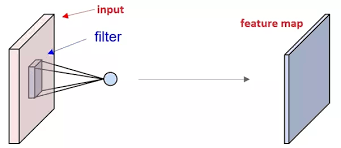

Feature maps have several important properties:

- Spatial Dimensions: Feature maps retain the spatial dimensions of the input. For example, if the input is a 2D image, the feature maps will also be 2D, preserving the height and width information.

- Depth Channels: The depth of a feature map corresponds to the number of filters applied during convolution. Each filter produces a separate feature map, resulting in a stack of feature maps along the depth dimension.

- Activation Values: Each element in a feature map represents the activation value of a specific location in the input. Higher activation values indicate the presence of the learned feature at that location.

- Hierarchical Representation: CNNs typically consist of multiple convolutional layers. The feature maps generated by earlier layers capture low-level features, such as edges and textures, while the feature maps in deeper layers represent higher-level, more abstract features.

By stacking multiple convolutional layers, CNNs can learn increasingly complex representations of the input data. These feature maps enable the network to extract meaningful features and patterns, making CNNs powerful for tasks such as image classification, object detection, and image segmentation.

#### **The steps you will follow to visualize the feature maps**

- Define a modell that will take an image as the input. The output of the model will be feature maps, which are an intermediate representation for all layers after the first layer. This is based on the model we have used for training.
- Load the input image for which we want to view the Feature map to understand which features were prominent to classify the image.
- Convert the image to NumPy array in the form of weights
- Normalize the array by rescaling it.
- Run the input image through the visualization model to obtain all
intermediate representations for the input image.


#### **What is MNIST Dataset**

The MNIST dataset is a widely used benchmark dataset in the field of machine learning and computer vision. MNIST stands for Modified National Institute of Standards and Technology database. It is a collection of grayscale images of handwritten digits (0-9) along with their corresponding labels or target values.

The dataset consists of two main components: a training set and a test set. The training set contains 60,000 images, while the test set contains 10,000 images. The images in both sets have a fixed size of 28x28 pixels.

The MNIST dataset is commonly used for tasks such as image classification and digit recognition. It serves as a foundational dataset for researchers and practitioners to develop and evaluate various machine learning algorithms, particularly in the context of deep learning and neural networks.

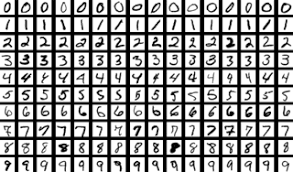

### **Importing Libraries**

In [1]:
# Importing TensorFlow library
import tensorflow as tf
# Importing Keras module from TensorFlow
from tensorflow import keras
# Importing Matplotlib for visualization
import matplotlib.pyplot as plt
# Importing NumPy for numerical computations
import numpy as np
# Magic command to display plots inline in Jupyter Notebook
%matplotlib inline
# Importing the MNIST dataset
from keras.datasets import mnist
# Importing utility functions for one-hot encoding
from keras.utils import to_categorical
# Importing Sequential and Model classes for building models
from keras.models import Sequential, Model
# Importing different types of layers for the model
from keras.layers import Dense, Activation, Dropout, Conv2D, AveragePooling2D, MaxPooling2D, Flatten
# Importing Adam optimizer for model training
from keras.optimizers import Adam

I0000 00:00:1790325740.288993   20680 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790325740.328340   20680 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790325741.392868   20680 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### **Loading the dataset**

In [2]:
# Load the MNIST dataset and split it into training and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

### **Understanding the data**

In [3]:
# Get the length of the training set
len(X_train)

60000

In [4]:
# Get the length of the test set
len(X_test)

10000

In [5]:
# Get the shape of the first training sample
X_train[0].shape

(28, 28)

In [6]:
# two dimensional data
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

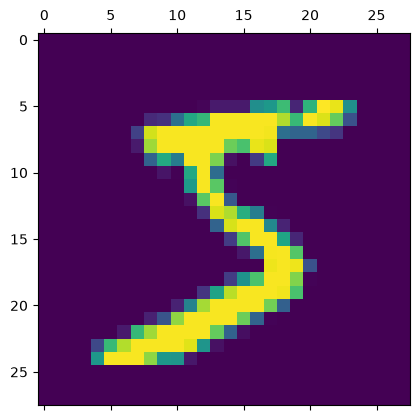

In [7]:
# input image of the training data
plt.matshow(X_train[0])

In [8]:
#plt.matshow(X_train[2])

In [9]:
#plt.matshow(X_train[7])

In [10]:
Y_train[2]

4

In [11]:
Y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [12]:
width = height = X_train.shape[1]

### **Pre-processing**

In [13]:
#assigns the maximum value of the RGB scale
max_rbg_value = 255

#Reshaping and normalization of the training data
X_train = X_train.reshape((X_train.shape[0],
                          width,
                          height,
                          1)).astype(np.float32)/max_rbg_value

#Reshaping and normalization of the test data
X_test = X_test.reshape((X_test.shape[0],
                          width,
                          height,
                          1)).astype(np.float32)/max_rbg_value

#One-hot encoding of the training and testing labels
Y_train = to_categorical(Y_train, num_classes=10)
Y_test = to_categorical(Y_test, num_classes=10)

### **Model Creation**

In [14]:
# Creating a sequential model
from keras import Input 
model = Sequential()
model.add(Input(shape=(width, height, 1)))          # <-- explicit Input layer

model.add(Dropout(.25, seed=1000))
model.add(Conv2D(filters=16, kernel_size=(3,3), padding='same'))
model.add(Activation('relu'))
model.add(Dropout(.5, seed=1000))

model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same')) 
model.add(Activation('relu'))       # Adding a ReLU activation function
model.add(Dropout(.5, seed=1000))   # Adding a dropout layer with a dropout rate of 0.5

model.add(AveragePooling2D(pool_size=(2,2), padding='same'))  # Adding an average pooling layer with a pool size of 2x2 and 'same' padding

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same'))  # Adding another 2D convolutional layer with 64 filters and a kernel size of 3x3
model.add(Activation('relu'))   # Adding a ReLU activation function

model.add(AveragePooling2D(pool_size=(2,2), padding='same'))  # Adding an average pooling layer with a pool size of 2x2 and 'same' padding

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same'))  # Adding another 2D convolutional layer with 64 filters and a kernel size of 3x3
model.add(Activation('relu'))    # Adding a ReLU activation function
model.add(Dropout(.5, seed=1000))   # Adding a dropout layer with a dropout rate of 0.5

model.add(AveragePooling2D(pool_size=(2,2), padding='same'))    # Adding an average pooling layer with a pool size of 2x2 and 'same' padding

model.add(Flatten())    # Flattening the previous layer

model.add(Dense(1024))  # Adding a fully connected layer with 1024 units
model.add(Activation('relu'))  # Adding a ReLU activation function
model.add(Dropout(.5, seed=1000))  # Adding a dropout layer with a dropout rate of 0.5

model.add(Dense(10))  # Adding a fully connected layer with 10 units (for 10 classes in the output)
model.add(Activation('softmax'))  # Adding a softmax activation function

# model.compile(optimizer=Adam(lr=.001, decay=1e-5),  # Compiling the model with Adam optimizer, learning rate of 0.001, and a decay rate of 1e-5
#               loss='categorical_crossentropy',  # Using categorical cross-entropy as the loss function
#               metrics=['accuracy'])  # Specifying 'accuracy' as the evaluation metric

model.compile(optimizer=Adam(learning_rate=.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

I0000 00:00:1790325743.078968   20680 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4139 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [15]:
#Summary of Model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 7, 7, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 4, 4, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,120,074 (4.27 MB)

 Trainable params: 1,120,074 (4.27 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Training model
history = model.fit(X_train, Y_train,
                   epochs=3,
                   batch_size=256,
                   validation_data=(X_test, Y_test))

Epoch 1/3


I0000 00:00:1790325745.257416   20747 service.cc:153] XLA service 0x7c66a8034e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790325745.257437   20747 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790325745.285742   20747 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790325745.519264   20747 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790325745.614199   20747 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2732__.48
I0000 00:00:1790325747.667514   20819 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 712 bytes spill stores, 712 bytes spill loads

I0000 00:00:1790325748.463905   20816 subprocess_compilation.cc

 14/235 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2946 - loss: 2.0009

I0000 00:00:1790325753.874831   20747 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8413 - loss: 0.4830

I0000 00:00:1790325756.949412   20747 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2732__.48
I0000 00:00:1790325757.635420   21153 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 712 bytes spill stores, 712 bytes spill loads

I0000 00:00:1790325758.342875   21148 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 812 bytes spill stores, 812 bytes spill loads



235/235 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.8414 - loss: 0.4826 - val_accuracy: 0.9652 - val_loss: 0.1201
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9492 - loss: 0.1587 - val_accuracy: 0.9781 - val_loss: 0.0869
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9629 - loss: 0.1199 - val_accuracy: 0.9836 - val_loss: 0.0522


In [17]:
history.history

{'accuracy': [0.8414333462715149, 0.9491999745368958, 0.962933361530304],
 'loss': [0.48259469866752625, 0.15873005986213684, 0.11989514529705048],
 'val_accuracy': [0.9652000069618225, 0.9781000018119812, 0.9836000204086304],
 'val_loss': [0.12010207772254944, 0.08689162135124207, 0.0521952286362648]}

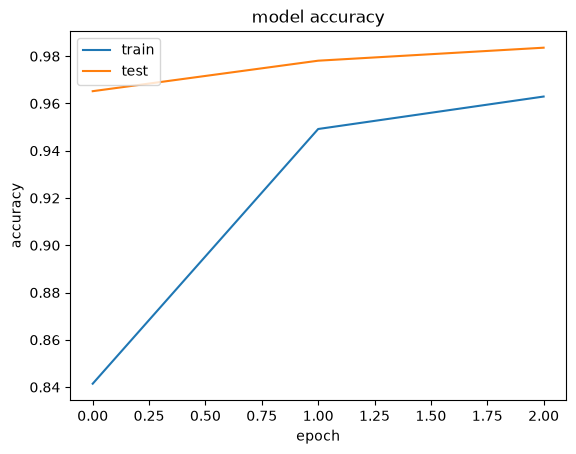

In [18]:
# Plotting train history:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

### **Visualization of feature maps**


In [19]:
# summarize filter shapes
for layer in model.layers:
    # check for convolutional layer
    if 'conv' not in layer.name:
        continue
    # get filter weights
    filters, biases = layer.get_weights()
    print(layer.name, filters.shape)

conv2d (3, 3, 1, 16)
conv2d_1 (3, 3, 16, 32)
conv2d_2 (3, 3, 32, 64)
conv2d_3 (3, 3, 64, 64)


In [20]:
# retrieve weights from the second hidden layer
filters, biases = model.layers[1].get_weights()

In [21]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

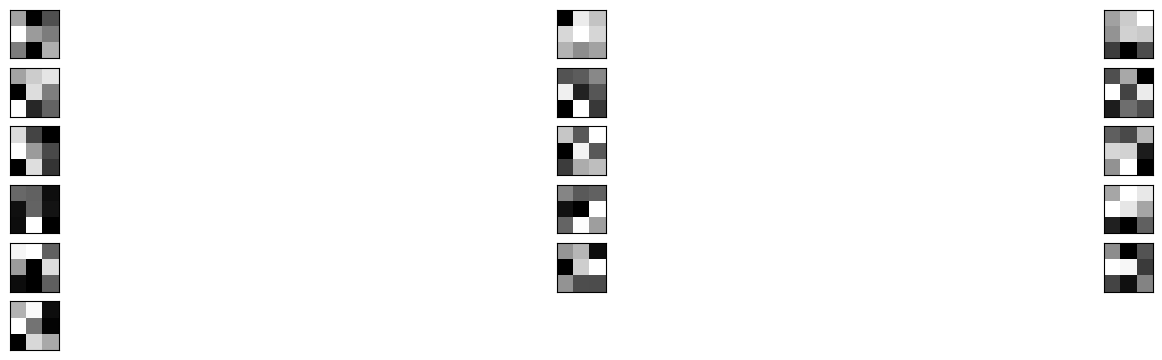

In [22]:
# plot first few filters
n_filters, ix = 16, 1
plt.figure(figsize=(20,12))
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # plot each channel separately
    for j in range(1):
        # specify subplot and turn of axis
        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1
# show the figure
plt.show()

In [23]:
feature_map_model = Model(inputs=model.inputs, outputs=model.layers[1].output)

feature_map_model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160 (640.00 B)

 Trainable params: 160 (640.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
feature_maps = feature_map_model.predict(X_train[0].reshape(1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


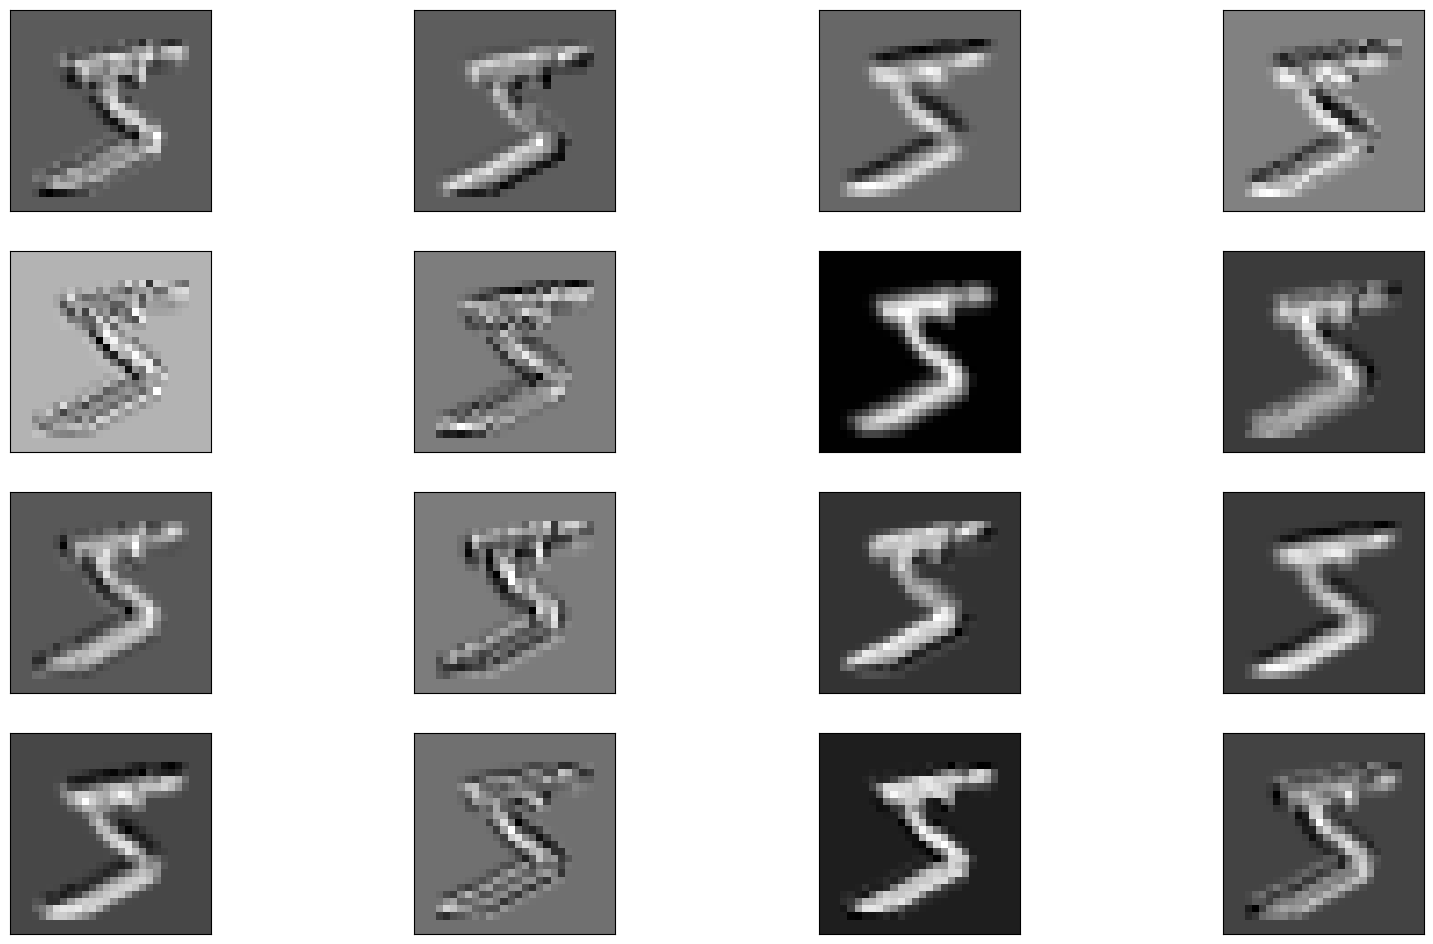

In [25]:
square = 4
ix = 1
plt.figure(figsize=(20,12))

for _ in range(square):
    for _ in range(square):
        # specify subplot and turn of axis
        ax = plt.subplot(square, square, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
        ix += 1
# show the figure
plt.show()

In [26]:
# print feature map from deeper layer

deep_layer = Model(inputs=model.inputs, outputs=model.layers[9].output)
deep_layer.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,296 (91.00 KB)

 Trainable params: 23,296 (91.00 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
feature_maps = deep_layer.predict(X_train[0].reshape(1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step


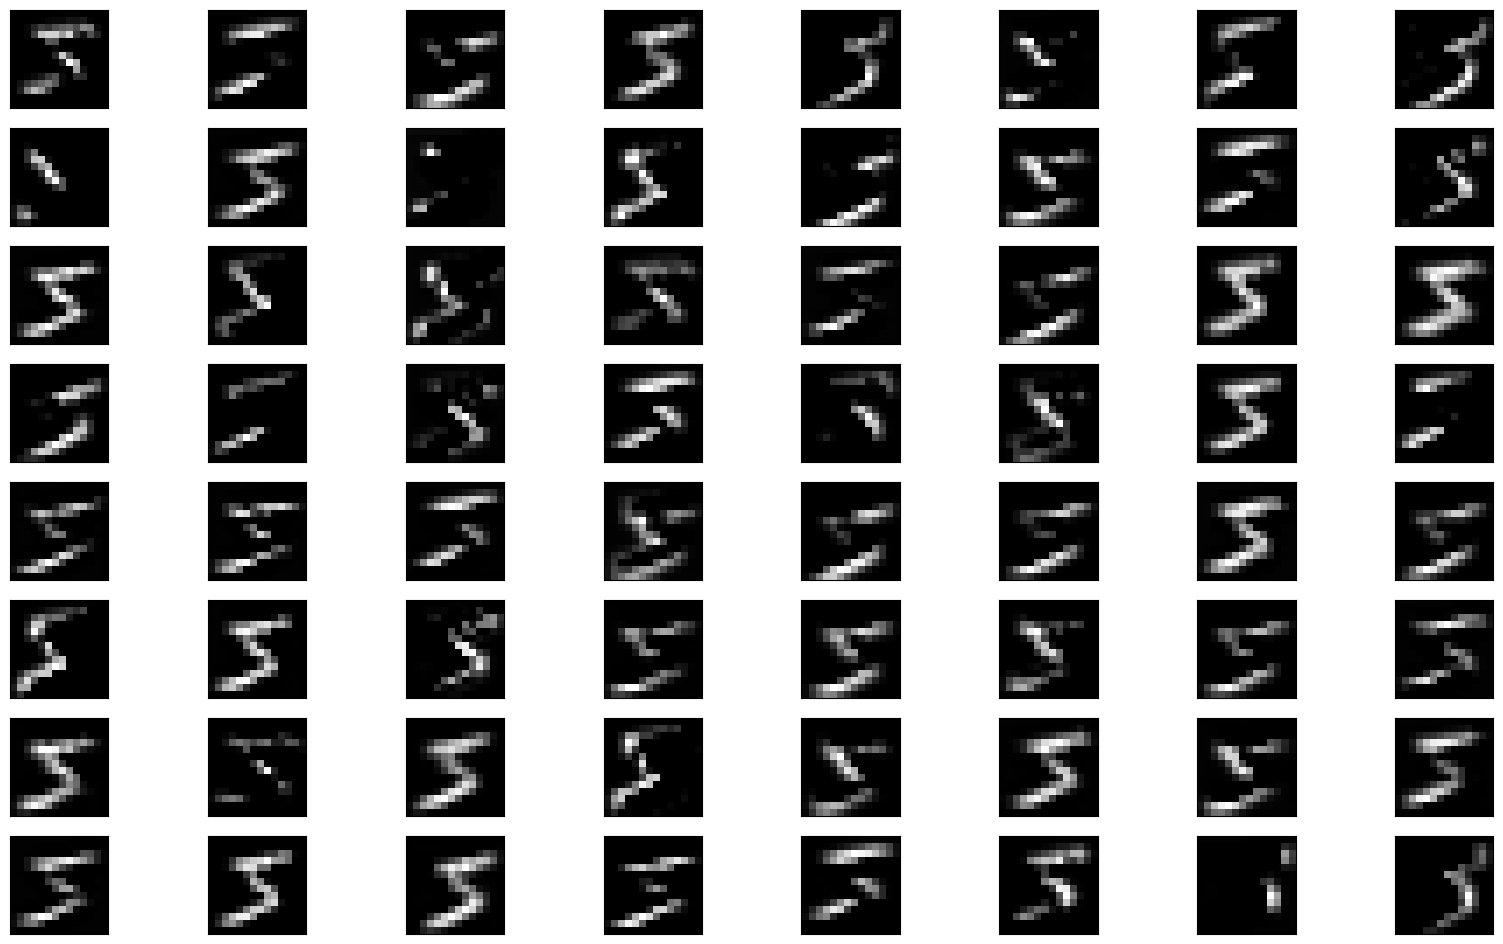

In [28]:
square = 8
ix = 1
plt.figure(figsize=(20,12))

for _ in range(square):
    for _ in range(square):
        # specify subplot and turn of axis
        ax = plt.subplot(square, square, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
        ix += 1
# show the figure
plt.show()